In [22]:
import tensorflow as tf
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.preprocessing import load_and_preprocess_data
import matplotlib.pyplot as plt

In [23]:
# Load and preprocess data
x_train, x_test, y_train, y_test = load_and_preprocess_data('../data/raw/weather.csv')
input_shape = x_train.shape

train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test))

In [24]:
# Batch and shuffle dataset
BATCH_SIZE = 64
SHUFFLE_BUFFER_SIZE = 100
train_dataset = train_dataset.shuffle(SHUFFLE_BUFFER_SIZE).batch(BATCH_SIZE)
test_dataset = test_dataset.batch(BATCH_SIZE)

In [25]:
# Buffer dataset
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

In [37]:
# Build a Sequential model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(input_shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1)
])
    
# Model summary
model.summary()
    
# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(), 
              loss=tf.keras.losses.BinaryCrossentropy(), 
              metrics=[tf.keras.metrics.BinaryAccuracy(threshold=0.5)])

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 64)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,161 (16.25 KB)

 Trainable params: 4,161 (16.25 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
# Train the model
epochs = 10

# Check if GPU is available
if tf.config.list_physical_devices('GPU'):
    with tf.device('/GPU:0'):
        # Use GPU if available
        print("Training on GPU")
        history = model.fit(train_dataset, epochs=epochs, validation_data=test_dataset)
else:
    # Use CPU if GPU is not available
    print("Training on CPU")
    history = model.fit(train_dataset, epochs=epochs, validation_data=test_dataset)
    
# Save the model
model.save('rainfall_forecasting_ann_model.keras')

Training on GPU
Epoch 1/10
2061/2061 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - binary_accuracy: 0.7149 - loss: 0.5848 - val_binary_accuracy: 0.7641 - val_loss: 0.4757
Epoch 2/10
2061/2061 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - binary_accuracy: 0.7606 - loss: 0.4858 - val_binary_accuracy: 0.7699 - val_loss: 0.4652
Epoch 3/10
2061/2061 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - binary_accuracy: 0.7722 - loss: 0.4638 - val_binary_accuracy: 0.7312 - val_loss: 0.5327
Epoch 4/10
2061/2061 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - binary_accuracy: 0.7648 - loss: 0.4761 - val_binary_accuracy: 0.7636 - val_loss: 0.4845
Epoch 5/10
2061/2061 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - binary_accuracy: 0.7762 - loss: 0.4593 - val_binary_accuracy: 0.7806 - val_loss: 0.4517
Epoch 6/10
2061/2061 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - binary_accuracy: 0.7817 - loss: 0.4532 - val_binary_accuracy: 0.7789 - val_loss: 0.4512
Epoch 7/10
2061/2061 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - binary_accuracy: 0.7664 - loss: 0.4779 - val_binary_accur

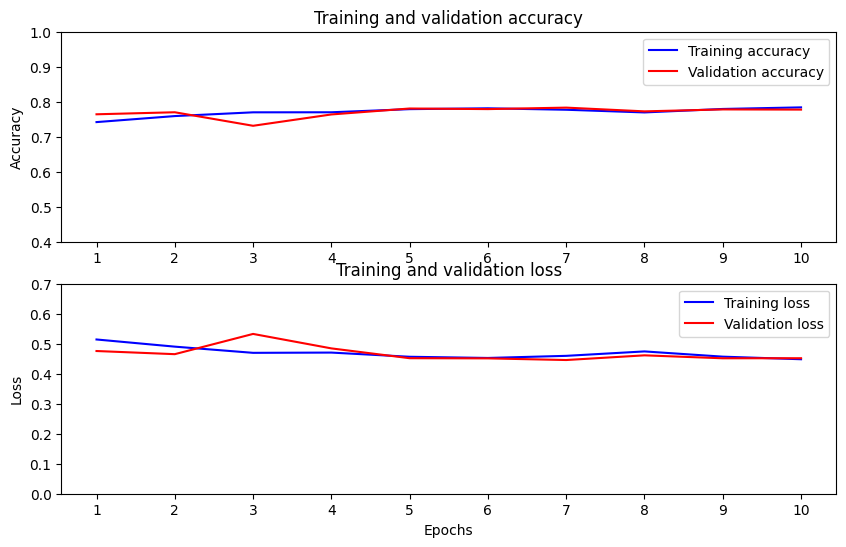

In [39]:
# Evaluate the model
accuracy = history.history['binary_accuracy']
val_accuracy = history.history['val_binary_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, epochs + 1)    

plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(epochs, accuracy, 'b', label='Training accuracy')
plt.plot(epochs, val_accuracy, 'r', label='Validation accuracy')
plt.ylabel('Accuracy')
plt.ylim(0.4, 1)
plt.xticks(epochs)
plt.title('Training and validation accuracy')
plt.legend()
    
plt.subplot(2, 1, 2)
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.ylabel('Loss')
plt.ylim(0, 0.7)
plt.xticks(epochs)
plt.xlabel('Epochs')
plt.title('Training and validation loss')
plt.legend()
plt.show()